**Problem No**: 03

**Problem Statement**: Take an 8-bit grayscale and apply smoothing operation by using weighted averaging filter (with and without built in smoothing function). Show both input and output image side by side in a subplot with a title)

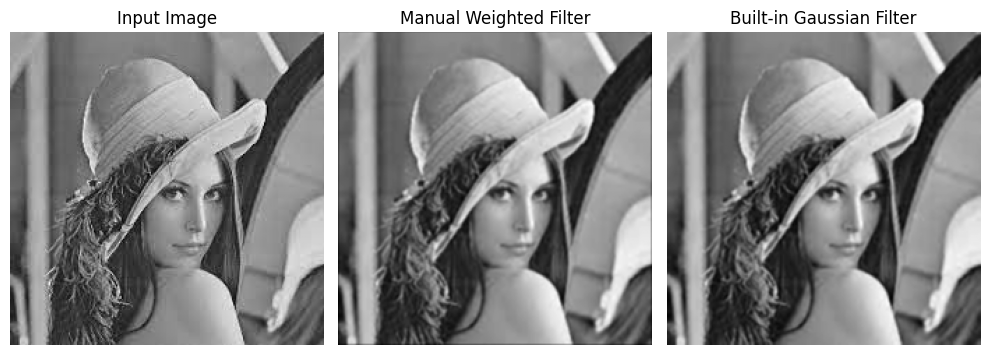

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read grayscale image
image = cv2.imread('./a.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Weighted kernel (Gaussian-like)
k = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
]) / 16

# =========================
# Manual Weighted Filtering
# =========================
padded = np.pad(image_gray, 1, mode="constant", constant_values=0)
manual_out = np.zeros_like(image_gray)

for i in range(1, padded.shape[0] - 1):
    for j in range(1, padded.shape[1] - 1):
        region = padded[i-1:i+2, j-1:j+2]
        manual_out[i-1, j-1] = np.sum(region * k)

# Clip to valid 8-bit range
manual_out = np.clip(manual_out, 0, 255).astype(np.uint8)

# =========================
# Built-in Weighted Filter
# =========================
builtin_out = cv2.GaussianBlur(image_gray, (3, 3), 0)

# =========================
# Plotting
# =========================
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_gray, cmap='gray')
plt.title("Input Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(manual_out, cmap='gray')
plt.title("Manual Weighted Filter")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(builtin_out, cmap='gray')
plt.title("Built-in Gaussian Filter")
plt.axis('off')

plt.tight_layout()
plt.show()